# EDA — Feux de forêt (BDIFF)

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
conn = sqlite3.connect("incendies.db")

COL_DATE = "Date de première alerte"
COL_SURFACE = "Surface parcourue (m2)"
COL_CAUSE = "Nature"
COL_INSEE_INCENDIES = "Code INSEE"
COL_INSEE_COMMUNES = "code_insee"
COL_LAT = "latitude_centre"
COL_LON = "longitude_centre"
COL_REGION = "reg_nom"          
COL_DEPARTEMENT = "dep_nom" 
COL_SUPERFICIE = "superficie_hectare"

incendies = pd.read_sql("SELECT * FROM incendies", conn)
communes = pd.read_sql("SELECT * FROM communes", conn)


In [2]:
pd.read_csv("data/Incendies_2015_2024.csv", sep=";", skiprows=3, nrows=0).columns.tolist()

['2015,12057,2A,2A362,Zonza,2015-01-01 15:16:00,4000,,4000.0,,,,,,,,,,,,,,,']

## Qualité des données

In [3]:
# doublons communes
communes[COL_INSEE_COMMUNES].duplicated().sum()


np.int64(0)

In [4]:
communes = communes.drop_duplicates(subset=COL_INSEE_COMMUNES)


In [5]:
# doublons incendies
incendies.duplicated().sum()


np.int64(0)

In [6]:
df = incendies.merge(communes, left_on=COL_INSEE_INCENDIES, right_on=COL_INSEE_COMMUNES, how="inner")
df[COL_DATE] = pd.to_datetime(df[COL_DATE])
df["mois"] = df[COL_DATE].dt.month
df["annee"] = df[COL_DATE].dt.year
df.shape


(139338, 65)

In [7]:
df["surface_ha"] = df[COL_SURFACE] / 10000
COL_SURFACE = "surface_ha"

In [8]:
# valeurs manquantes par colonne, en %
(df.isna().mean() * 100).round(2).sort_values(ascending=False)


Nombre de bâtiments partiellement détruits    99.38
Nombre de décès                               99.38
Nombre de bâtiments totalement détruits       99.38
Précision de la donnée                        99.13
Autres surfaces (m2)                          97.09
                                              ...  
altitude_minimale                              0.00
grille_densite                                 0.00
url_villedereve                                0.00
mois                                           0.00
surface_ha                                     0.00
Length: 66, dtype: float64

In [9]:
# outliers sur la surface (méthode IQR)
q1, q3 = df[COL_SURFACE].quantile([0.25, 0.75])
iqr = q3 - q1
seuil = q3 + 1.5 * iqr

n_outliers = (df[COL_SURFACE] > seuil).sum()
print(f"{n_outliers} outliers ({n_outliers / df[COL_SURFACE].notna().sum() * 100:.2f}%), seuil = {seuil:.1f}")

df[df[COL_SURFACE] > seuil].sort_values(COL_SURFACE, ascending=False).head(10)


18287 outliers (13.12%), seuil = 3.7


,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),...,latitude_mairie,longitude_mairie,latitude_centre,longitude_centre,grille_densite,gentile,url_wikipedia,url_villedereve,mois,surface_ha
132940,2022,11421,33,33225,Landiras,2022-07-12 16:31:00,125520000,125520000.0,NaN,0.0,...,44.567,-0.443,44.567,-0.443,Bourgs ruraux,Landiranais,https://fr.wikipedia.org/wiki/fr:Landiras,https://villedereve.fr/ville/33225-landiras,7,12552.0
52103,1990,3168,83,83148,Vidauban,1990-09-21 16:59:00,115800000,54426000.0,55584000.0,0.0,...,43.402,6.449,43.402,6.449,Petites villes,Vidaubannais,https://fr.wikipedia.org/wiki/fr:Vidauban,https://villedereve.fr/ville/83148-vidauban,9,11580.0
51427,1990,3104,83,83043,Collobrières,1990-08-21 15:24:00,96000000,45120000.0,46080000.0,0.0,...,43.241,6.340,43.241,6.340,Bourgs ruraux,Collobittérois(oise)s,https://fr.wikipedia.org/wiki/fr:Collobrières,https://villedereve.fr/ville/83043-collobrieres,8,9600.0
130317,2021,8934,83,83067,Gonfaron,2021-08-16 17:43:00,68320000,54280000.0,9580000.0,NaN,...,43.321,6.300,43.321,6.300,Bourgs ruraux,Gonfaronnais,https://fr.wikipedia.org/wiki/fr:Gonfaron,https://villedereve.fr/ville/83067-gonfaron,8,6832.0
83896,2003,8238,83,83148,Vidauban,2003-07-17 14:35:00,67440000,31696800.0,32371200.0,0.0,...,43.402,6.449,43.402,6.449,Petites villes,Vidaubannais,https://fr.wikipedia.org/wiki/fr:Vidauban,https://villedereve.fr/ville/83148-vidauban,7,6744.0
134416,2022,11419,33,33225,Landiras,2022-08-12 12:36:00,67427000,67427000.0,NaN,0.0,...,44.567,-0.443,44.567,-0.443,Bourgs ruraux,Landiranais,https://fr.wikipedia.org/wiki/fr:Landiras,https://villedereve.fr/ville/33225-landiras,8,6742.7
8452,1976,2495,66,66056,Corbère-les-Cabanes,1976-07-28 12:30:00,66000000,31020000.0,31680000.0,0.0,...,42.660,2.682,42.660,2.682,Bourgs ruraux,"Corbériens, Corbériennes",https://fr.wikipedia.org/wiki/fr:Corbère-les-C...,https://villedereve.fr/ville/66056-corbere-les...,7,6600.0
18303,1979,3871,83,83073,Le Luc,1979-08-10 16:00:00,58800000,27636000.0,28224000.0,0.0,...,43.380,6.306,43.380,6.306,Petites villes,"Lucoise, Lucois",https://fr.wikipedia.org/wiki/fr:Le Luc,https://villedereve.fr/ville/83073-le-luc,8,5880.0
132932,2022,11418,33,33529,La Teste-de-Buch,2022-07-12 14:36:00,57090000,57090000.0,NaN,0.0,...,44.556,-1.175,44.556,-1.175,Centres urbains intermédiaires,Testerins/Cazalins/Pylatais,https://fr.wikipedia.org/wiki/fr:La Teste-de-Buch,https://villedereve.fr/ville/33529-la-teste-de...,7,5709.0
84223,2003,8239,83,83148,Vidauban,2003-07-28 16:28:00,56460000,48840000.0,7620000.0,NaN,...,43.402,6.449,43.402,6.449,Petites villes,Vidaubannais,https://fr.wikipedia.org/wiki/fr:Vidauban,https://villedereve.fr/ville/83148-vidauban,7,5646.0


Checking for Outliers 

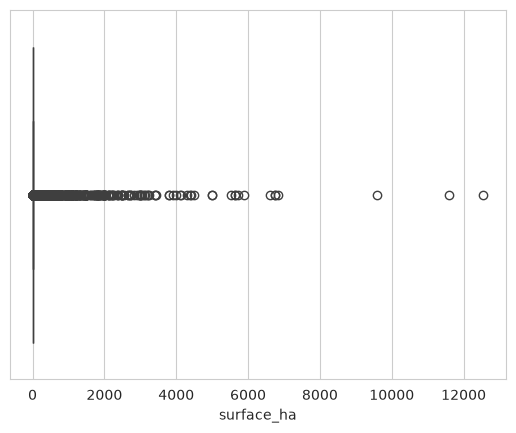

In [10]:
sns.boxplot(x=df[COL_SURFACE])
plt.show()


Check for outliers. Determine whether they result from a data entry error or not. One possible explanation is that the fire extended beyond the boundaries of its municipality because it had already spread beyond those boundaries at the time of the fire.

In [11]:
df["ratio_surface_commune"] = df["surface_ha"] / df["superficie_hectare"] 
df[df["ratio_surface_commune"] > 1].sort_values("ratio_surface_commune", ascending=False).head(10)

,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,gentile,url_wikipedia,url_villedereve,mois,surface_ha,ratio_surface_commune
8452,1976,2495,66,66056,Corbère-les-Cabanes,1976-07-28 12:30:00,66000000,31020000.0,31680000.0,0.0,...,2.682,42.660,2.682,Bourgs ruraux,"Corbériens, Corbériennes",https://fr.wikipedia.org/wiki/fr:Corbère-les-C...,https://villedereve.fr/ville/66056-corbere-les...,7,6600.00,15.827338
10371,1977,858,2B,2B034,Belgodère,1977-07-26 10:00:00,50000000,23500000.0,24000000.0,0.0,...,9.014,42.608,9.014,Rural à habitat dispersé,Belgodérais,https://fr.wikipedia.org/wiki/fr:Belgodère,https://villedereve.fr/ville/2B034-belgodere,7,5000.00,3.834356
29345,1982,1302,2A,2A191,Olmiccia,1982-09-04 11:00:00,43000000,20210000.0,20640000.0,0.0,...,9.033,41.670,9.033,Rural à habitat très dispersé,Olmicciens,https://fr.wikipedia.org/wiki/fr:Olmiccia,https://villedereve.fr/ville/2A191-olmiccia,9,4300.00,3.795234
13612,1978,3619,66,66034,Campôme,1978-08-31 10:00:00,20000000,9400000.0,9600000.0,0.0,...,2.384,42.643,2.384,Rural à habitat dispersé,Campomois,https://fr.wikipedia.org/wiki/fr:Campôme,https://villedereve.fr/ville/66034-campome,8,2000.00,3.738318
40772,1986,195,06,06095,Peymeinade,1986-08-23 14:30:00,34020000,15989400.0,16329600.0,0.0,...,6.882,43.630,6.882,Ceintures urbaines,Peymeinadois,https://fr.wikipedia.org/wiki/fr:Peymeinade,https://villedereve.fr/ville/06095-peymeinade,8,3402.00,3.425982
85085,2003,9110,2B,2B309,Santa-Maria-di-Lota,2003-08-26 15:38:00,43780200,20576694.0,21014496.0,0.0,...,9.425,42.751,9.425,Ceintures urbaines,"Lutinchi (Mandrialinchi, Figarellesi, Partinac...",https://fr.wikipedia.org/wiki/fr:Santa-Maria-d...,https://villedereve.fr/ville/2B309-santa-maria...,8,4378.02,3.284336
102053,2010,8346,34,34102,Fontanès,2010-08-30 15:58:00,25440000,22330000.0,530000.0,NaN,...,3.918,43.794,3.918,Rural à habitat dispersé,Fontanais,https://fr.wikipedia.org/wiki/fr:Fontanès (Hér...,https://villedereve.fr/ville/34102-fontanes,8,2544.00,3.057692
47953,1989,1562,2B,2B333,Vallecalle,1989-07-31 17:05:00,21250000,9987500.0,10200000.0,0.0,...,9.337,42.600,9.337,Rural à habitat très dispersé,NaN,https://fr.wikipedia.org/wiki/fr:Vallecalle,https://villedereve.fr/ville/2B333-vallecalle,7,2125.00,3.057554
40138,1986,165,06,06014,Bendejun,1986-07-24 12:15:00,18330000,8615100.0,8798400.0,0.0,...,7.284,43.830,7.284,Bourgs ruraux,Bendejunois,https://fr.wikipedia.org/wiki/fr:Bendejun,https://villedereve.fr/ville/06014-bendejun,7,1833.00,2.904913
37932,1985,2547,30,30079,Chambon,1985-09-09 00:30:00,41000000,19270000.0,19680000.0,0.0,...,4.019,44.306,4.019,Rural à habitat très dispersé,Chambonnard,https://fr.wikipedia.org/wiki/fr:Chambon (Gard),https://villedereve.fr/ville/30079-chambon,9,4100.00,2.831492


True → confirms the hypothesis (a fire affecting multiple municipalities counted as a single municipality) → a known limitation of BDIFF that needs to be documented; not an error


False → more likely actual data entry errors or a unit issue → needs to be investigated line by line

In [12]:
from math import radians, sin, cos, sqrt, atan2

def distance_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 6371 * 2 * atan2(sqrt(a), sqrt(1 - a))


def a_incendie_voisin_meme_jour(row, df, rayon_km=15):
    meme_jour = df[df[COL_DATE].dt.date == row[COL_DATE].date()]
    meme_jour = meme_jour[meme_jour[COL_INSEE_INCENDIES] != row[COL_INSEE_INCENDIES]]

    for _, r in meme_jour.iterrows():
        if distance_km(row[COL_LAT], row[COL_LON], r[COL_LAT], r[COL_LON]) <= rayon_km:
            return True
    return False


outliers = df[df["ratio_surface_commune"] > 1].copy()
outliers["incendie_voisin"] = outliers.apply(lambda r: a_incendie_voisin_meme_jour(r, df), axis=1)

outliers["incendie_voisin"].value_counts()

incendie_voisin
True     42
False    22
Name: count, dtype: int64

In [13]:
def a_incendie_voisin(row, df, rayon_km=20, jours=1):
    fenetre = df[(df[COL_DATE].dt.date - row[COL_DATE].date()).abs() <= pd.Timedelta(days=jours)]
    fenetre = fenetre[fenetre[COL_INSEE_INCENDIES] != row[COL_INSEE_INCENDIES]]

    for _, r in fenetre.iterrows():
        if distance_km(row[COL_LAT], row[COL_LON], r[COL_LAT], r[COL_LON]) <= rayon_km:
            return True
    return False


restants = outliers[~outliers["incendie_voisin"]].copy()
restants["incendie_voisin_elargi"] = restants.apply(lambda r: a_incendie_voisin(r, df), axis=1)
restants["incendie_voisin_elargi"].value_counts()

incendie_voisin_elargi
True     17
False     5
Name: count, dtype: int64

64 fires (X%) have an area-to-municipality ratio greater than 1. The hypothesis of cross-municipal spread (a single municipality recorded in BDIFF for a fire that extends beyond its boundaries) is plausible but could not be conclusively confirmed based on spatiotemporal proximity to other fires. These records are retained but marked with surface_reliable=False for analyses sensitive to area.

In [14]:
non_outliers = df[df["ratio_surface_commune"] <= 1].sample(50, random_state=0)
non_outliers["incendie_voisin"] = non_outliers.apply(lambda r: a_incendie_voisin(r, df, rayon_km=20, jours=1), axis=1)

print("taux voisin - outliers    :", outliers["incendie_voisin"].mean())
print("taux voisin - non-outliers:", non_outliers["incendie_voisin"].mean())

taux voisin - outliers    : 0.65625
taux voisin - non-outliers: 0.58


In [15]:
df["surface_fiable"] = df["ratio_surface_commune"].le(1) | df["ratio_surface_commune"].isna()
df["surface_fiable"].value_counts()

surface_fiable
True     139274
False        64
Name: count, dtype: int64

## Évolution annuelle

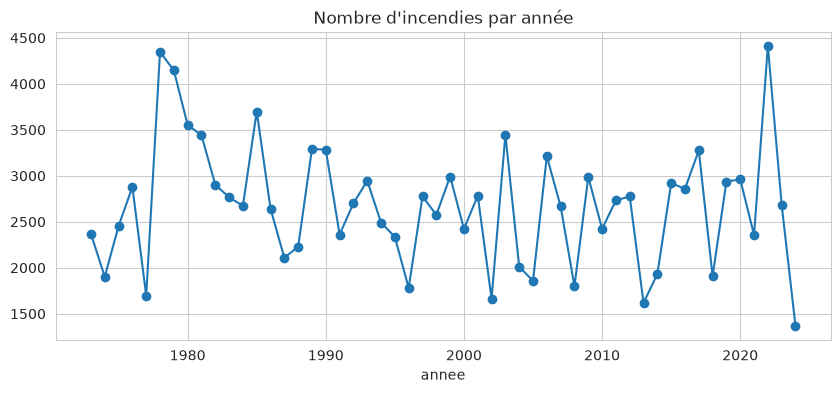

In [16]:
df.groupby("annee").size().plot(kind="line", marker="o", figsize=(10, 4), title="Nombre d'incendies par année")
plt.show()


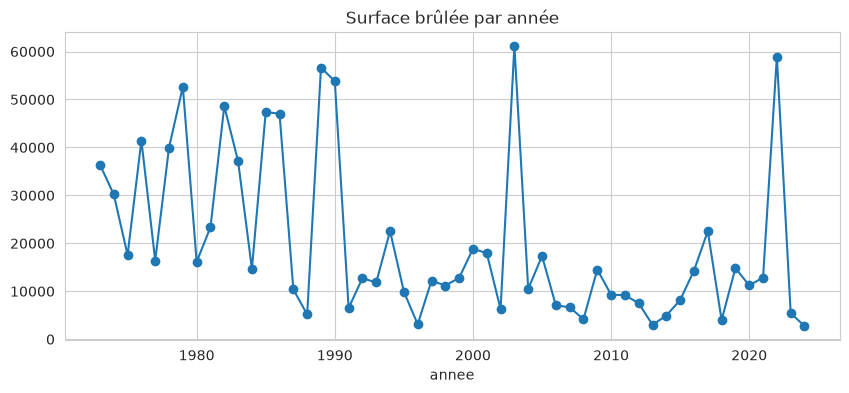

In [17]:
df.groupby("annee")[COL_SURFACE].sum().plot(kind="line", marker="o", figsize=(10, 4), title="Surface brûlée par année")
plt.show()


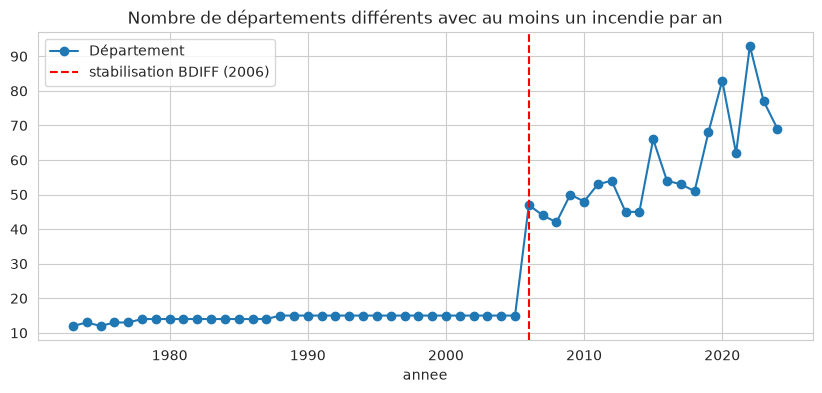

In [18]:
df.groupby("annee")["Département"].nunique().plot(kind="line", marker="o", figsize=(10, 4), title="Nombre de départements différents avec au moins un incendie par an")
plt.axvline(2006, color="red", linestyle="--", label="stabilisation BDIFF (2006)")
plt.legend()
plt.show()

## Saisonnalité

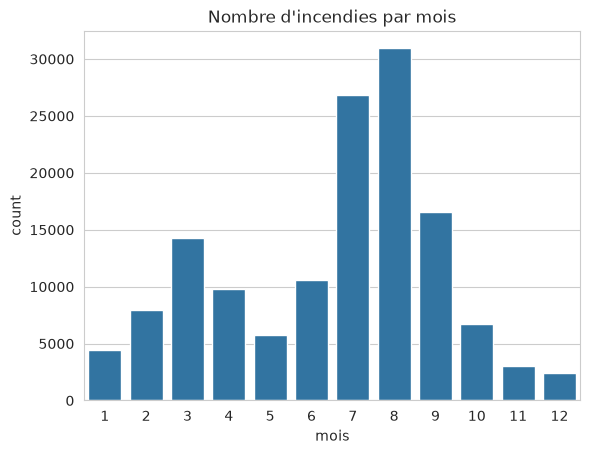

In [19]:
sns.countplot(x="mois", data=df)
plt.title("Nombre d'incendies par mois")
plt.show()


In [20]:
df["jour_semaine"] = df[COL_DATE].dt.dayofweek  # 0=lundi ... 6=dimanche
df["weekend"] = df["jour_semaine"].isin([5, 6])

df["weekend"].value_counts(normalize=True) * 100

weekend
False    70.954083
True     29.045917
Name: proportion, dtype: float64

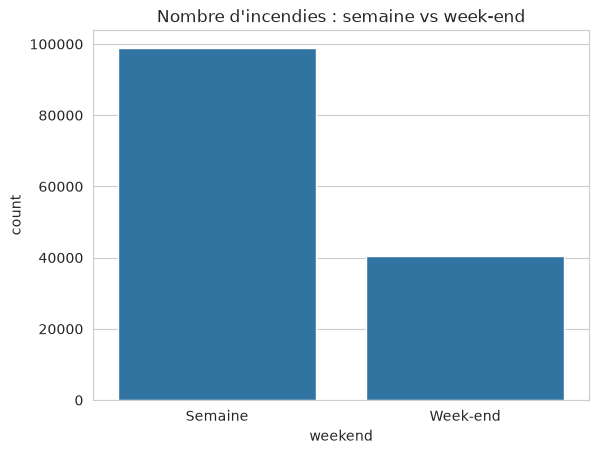

In [21]:
sns.countplot(x="weekend", data=df)
plt.xticks([0, 1], ["Semaine", "Week-end"])
plt.title("Nombre d'incendies : semaine vs week-end")
plt.show()

## Répartition géographique

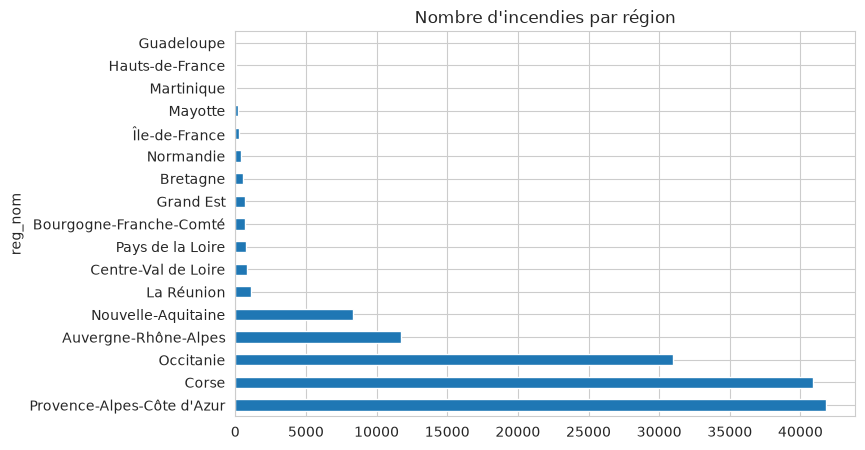

In [22]:
df[COL_REGION].value_counts().plot(kind="barh", figsize=(8, 5), title="Nombre d'incendies par région")
plt.show()


Surface forêt (m2)                             3.303478
Surface maquis garrigues (m2)                 16.679585
Autres surfaces naturelles hors forêt (m2)    25.237193
Surface autres terres boisées (m2)            87.964518
Surfaces non boisées naturelles (m2)          92.437095
Surfaces non boisées artificialisées (m2)     92.628716
Surfaces agricoles (m2)                       97.081198
Autres surfaces (m2)                          97.092681
dtype: float64


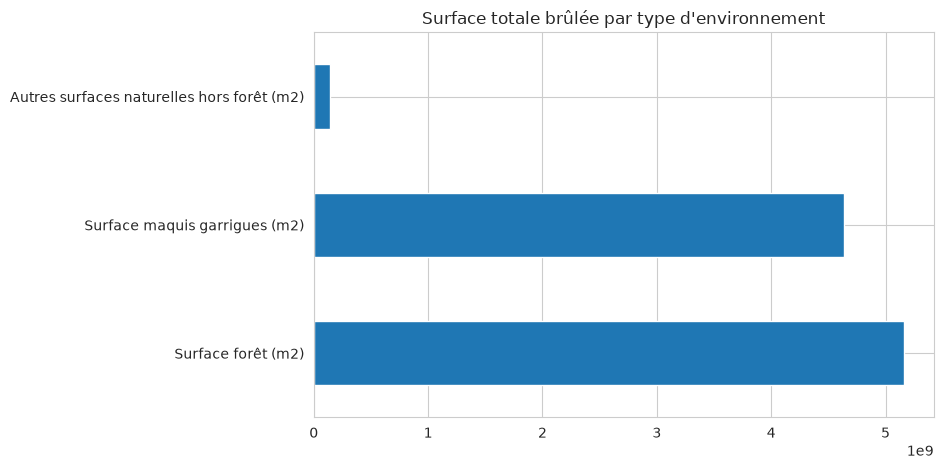

In [23]:
surface_types = [
    "Surface forêt (m2)",
    "Surface maquis garrigues (m2)",
    "Autres surfaces naturelles hors forêt (m2)",
    "Surfaces agricoles (m2)",
    "Autres surfaces (m2)",
    "Surface autres terres boisées (m2)",
    "Surfaces non boisées naturelles (m2)",
    "Surfaces non boisées artificialisées (m2)",
]

pct_missing = df[surface_types].isna().mean() * 100
print(pct_missing.sort_values())

cols_ok = pct_missing[pct_missing < 50].index.tolist()

if cols_ok:
    df[cols_ok].sum().sort_values(ascending=False).plot(kind="barh", figsize=(8, 5), title="Surface totale brûlée par type d'environnement")
    plt.show()
else:
    print("Colonnes trop incomplètes pour être exploitables, graphique ignoré.")

In [24]:
import folium
from folium.plugins import HeatMap

coords = df[[COL_LAT, COL_LON]].dropna()
sample = coords.sample(min(20000, len(coords)), random_state=0)

m = folium.Map(location=[46.6, 2.5], zoom_start=6)
HeatMap(sample.values.tolist(), radius=6, blur=8).add_to(m)
m.save("carte_incendies.html")

## Causes

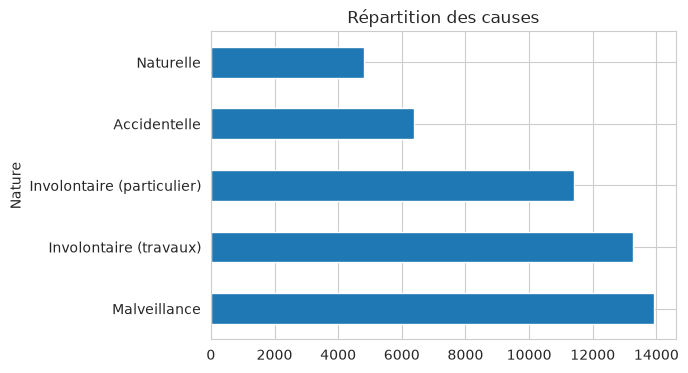

In [25]:
df[COL_CAUSE].value_counts().plot(kind="barh", figsize=(6, 4), title="Répartition des causes")
plt.show()


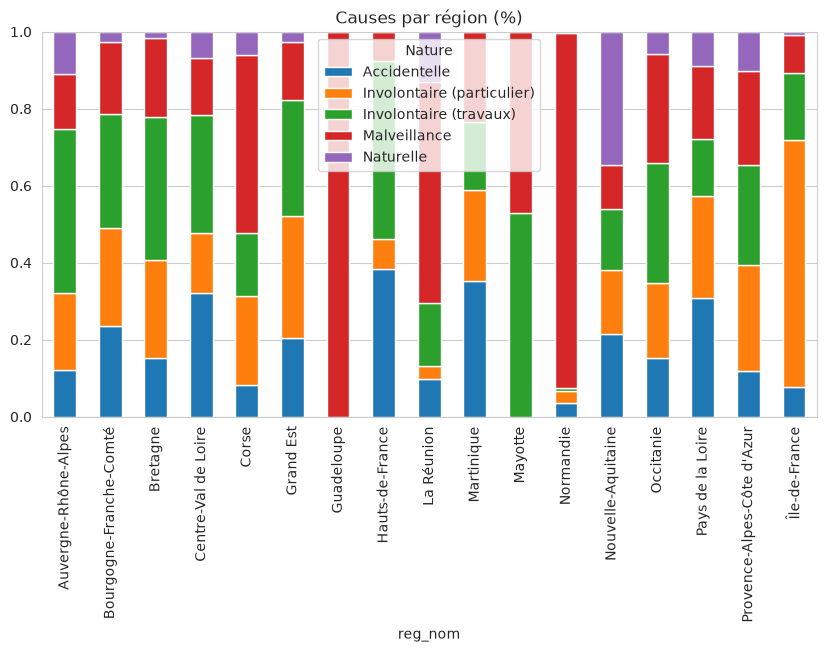

In [26]:
pd.crosstab(df[COL_REGION], df[COL_CAUSE], normalize="index").plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Causes par région (%)")
plt.show()


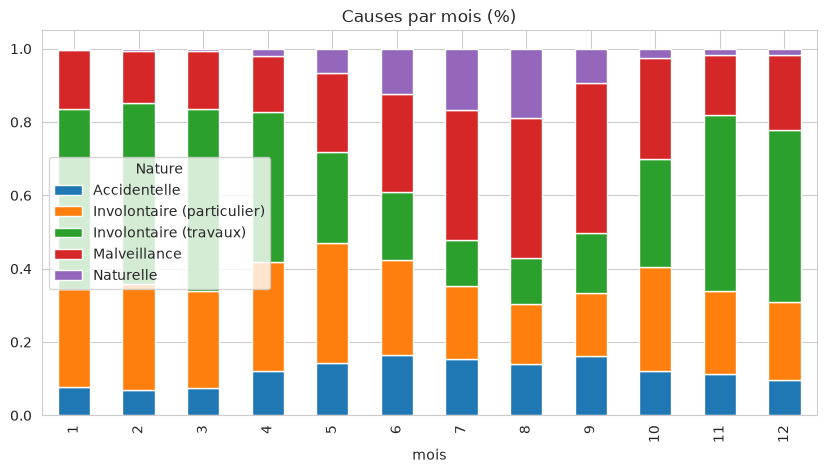

In [27]:
pd.crosstab(df["mois"], df[COL_CAUSE], normalize="index").plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Causes par mois (%)")
plt.show()


## Gravité

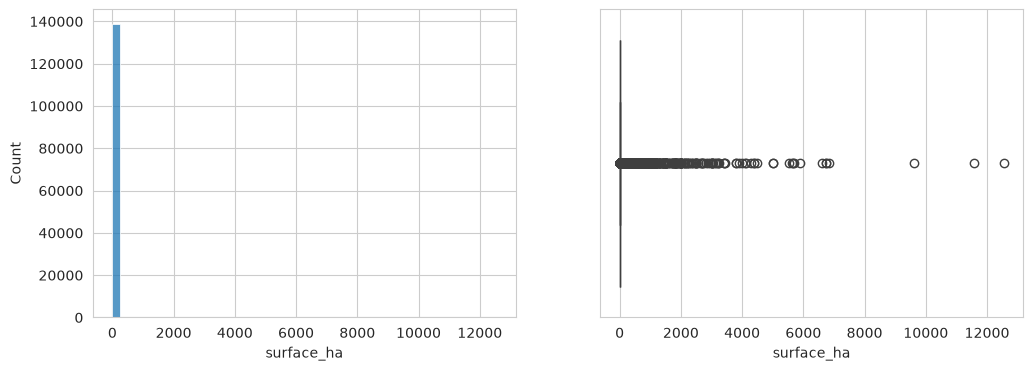

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[COL_SURFACE].dropna(), bins=50, ax=ax[0])
sns.boxplot(x=df[COL_SURFACE], ax=ax[1])
plt.show()


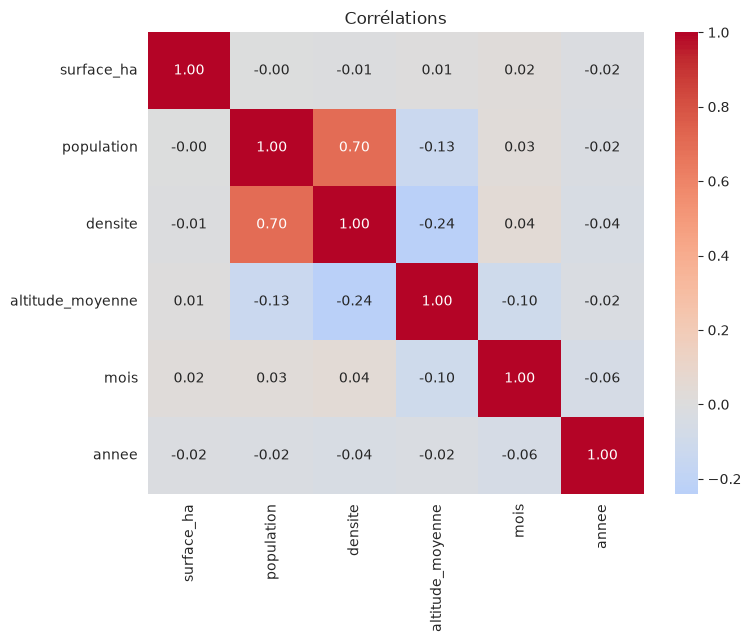

In [29]:
num_cols = ["surface_ha", "population", "densite", "altitude_moyenne", "mois", "annee"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations")
plt.show()

## Limites et biais à documenter

In [30]:
df.groupby("annee").size()


annee
1973    2368
1974    1901
1975    2454
1976    2878
1977    1696
1978    4347
1979    4147
1980    3552
1981    3442
1982    2903
1983    2766
1984    2673
1985    3699
1986    2642
1987    2107
1988    2230
1989    3293
1990    3283
1991    2361
1992    2700
1993    2946
1994    2491
1995    2335
1996    1779
1997    2776
1998    2575
1999    2992
2000    2422
2001    2783
2002    1663
2003    3445
2004    2010
2005    1858
2006    3212
2007    2667
2008    1798
2009    2987
2010    2423
2011    2732
2012    2776
2013    1618
2014    1931
2015    2920
2016    2859
2017    3275
2018    1908
2019    2937
2020    2961
2021    2356
2022    4412
2023    2682
2024    1367
dtype: int64

À compléter dans le rapport méthodologique :
- années avec très peu d'incendies ci-dessus = probable sous-déclaration / saisie incomplète
- couverture géographique inégale entre régions (voir répartition ci-dessus)
- % de valeurs manquantes sur surface/cause (voir étape SQL)
- codes INSEE orphelins non rattachés à une commune (voir étape SQL)

In [31]:
conn.close()
